In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.shape

(6435, 8)

In [ ]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
df['Month'] = df['Date'].dt.month

In [ ]:
df['Year'] = df['Date'].dt.year

In [ ]:
df['Day'] = df['Date'].dt.day_name()

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,Friday
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,Friday
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,Friday
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,Friday
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,Friday


In [ ]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,6.447552,2010.965035
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,1.000000,2010.000000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,4.000000,2010.000000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,6.000000,2011.000000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,9.000000,2012.000000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,12.000000,2012.000000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,3.238308,0.797019


In [ ]:
corr = df.corr(numeric_only=True)
corr

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531,2.910676e-15,3.474318e-12
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176,7.614332e-02,-1.837754e-02
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960,1.229958e-01,-5.678257e-02
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158,2.358618e-01,6.426923e-02
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684,-4.215590e-02,7.794703e-01
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020,4.979672e-03,7.479573e-02
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000,-1.274559e-02,-2.418135e-01
Month,2.910676e-15,0.076143,1.229958e-01,0.235862,-0.042156,0.004980,-0.012746,1.000000e+00,-1.944645e-01
Year,3.474318e-12,-0.018378,-5.678257e-02,0.064269,0.779470,0.074796,-0.241813,-1.944645e-01,1.000000e+00


In [ ]:
df = pd.read_csv('../Data/Walmart.csv')

In [ ]:
corr = df.corr(numeric_only=True)

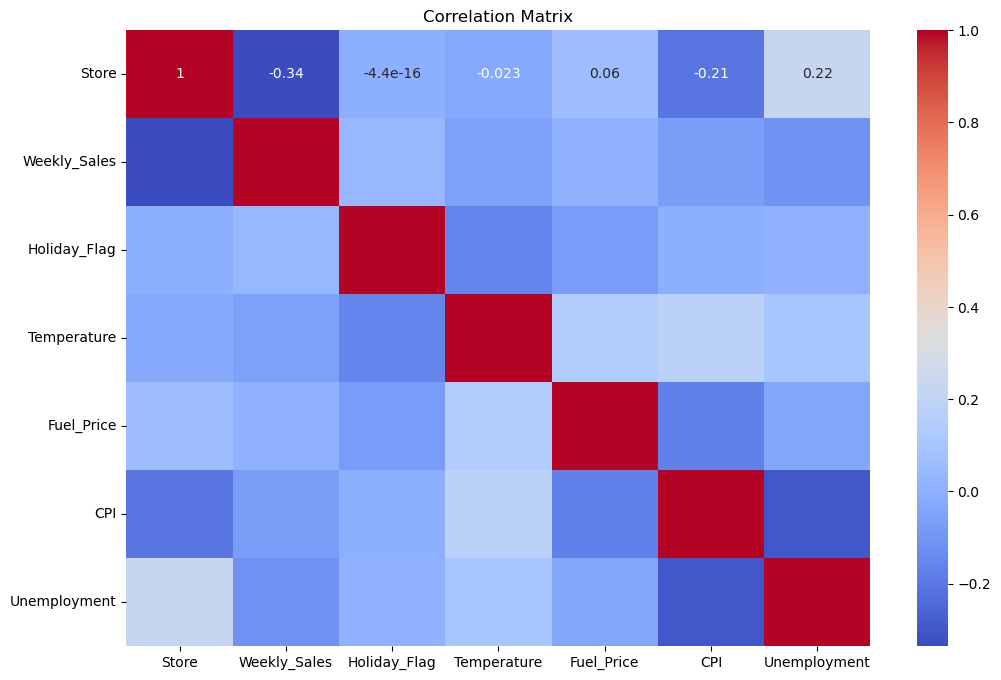

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.savefig('../Graph/heatmap.png')

plt.show()

c:\Users\Tanisha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


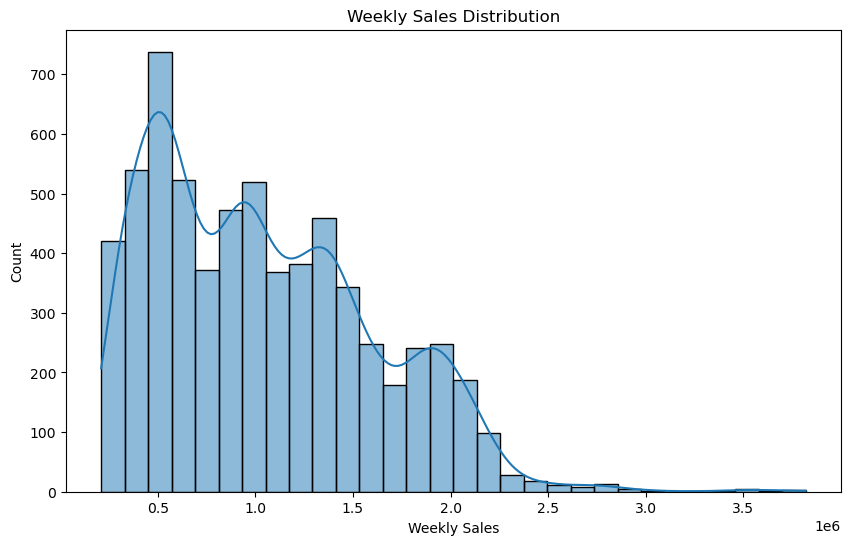

In [ ]:

plt.figure(figsize=(10,6))

sns.histplot(df['Weekly_Sales'], bins=30, kde=True)

plt.title('Weekly Sales Distribution')

plt.xlabel('Weekly Sales')
plt.ylabel('Count')

plt.savefig('../Graph/sales_distribution.png')

plt.show()

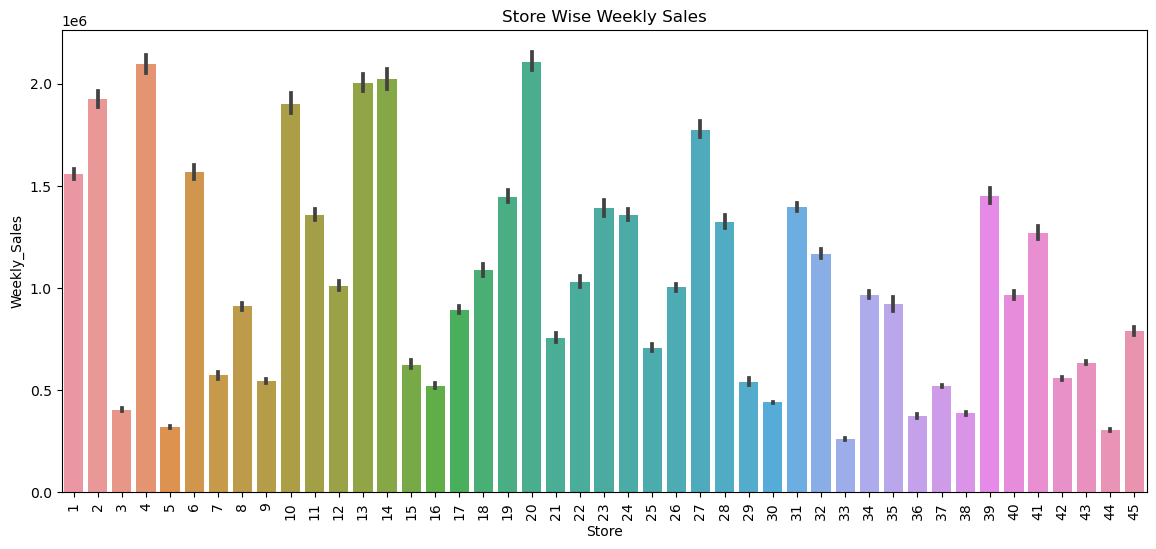

In [ ]:

plt.figure(figsize=(14,6))

sns.barplot(x='Store', y='Weekly_Sales', data=df)

plt.title('Store Wise Weekly Sales')

plt.xticks(rotation=90)

plt.savefig('../Graph/store_sales.png')

plt.show()

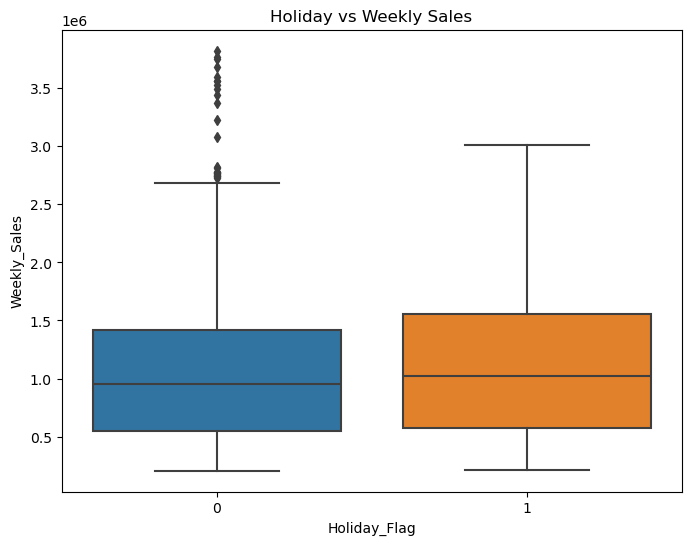

In [ ]:


plt.figure(figsize=(8,6))

sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)

plt.title('Holiday vs Weekly Sales')

plt.savefig('../Graph/holiday_sales.png')

plt.show()

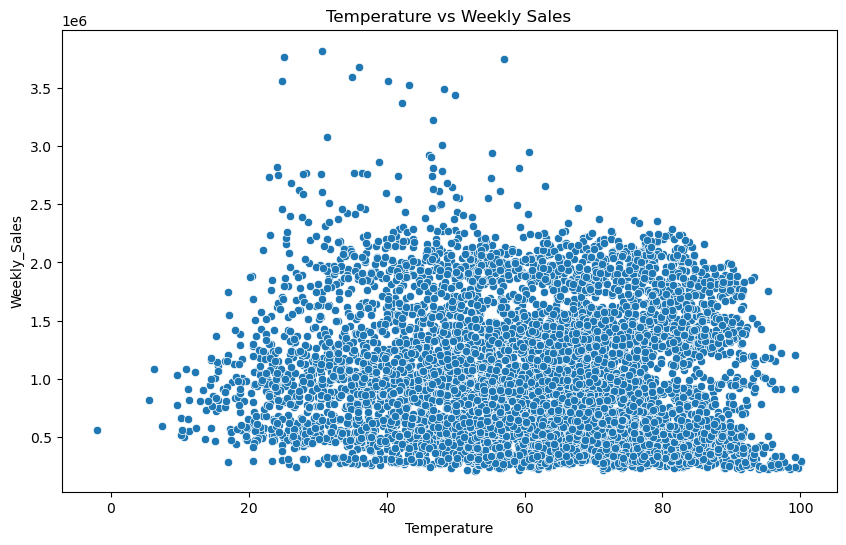

In [ ]:

plt.figure(figsize=(10,6))

sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)

plt.title('Temperature vs Weekly Sales')

plt.savefig('../Graph/temperature_sales.png')

plt.show()

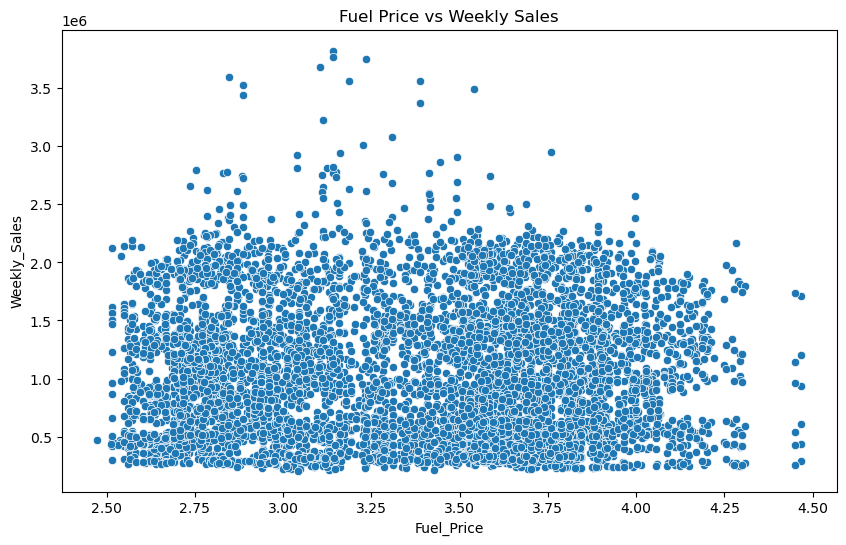

In [ ]:


plt.figure(figsize=(10,6))

sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df)

plt.title('Fuel Price vs Weekly Sales')

plt.savefig('../Graph/fuelprice_sales.png')

plt.show()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.month

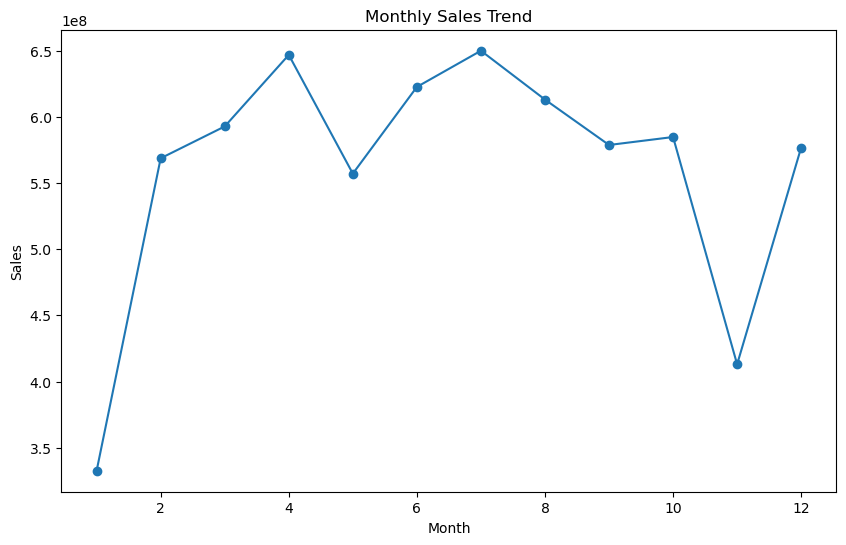

In [ ]:

monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()

plt.figure(figsize=(10,6))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')

plt.xlabel('Month')
plt.ylabel('Sales')

plt.savefig('../Graph/monthly_sales.png')

plt.show()

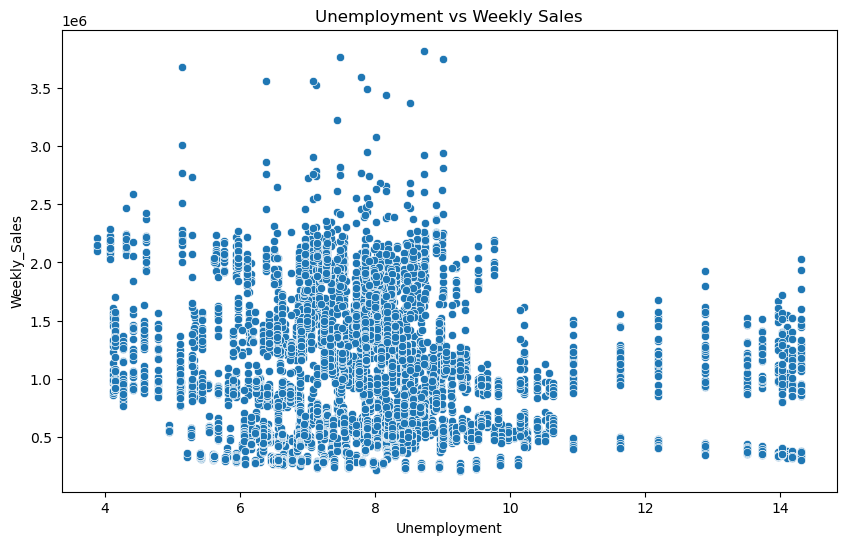

In [ ]:


plt.figure(figsize=(10,6))

sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df)

plt.title('Unemployment vs Weekly Sales')

plt.savefig('../Graph/unemployment_sales.png')

plt.show()

In [ ]:
# CLEANED DATASET SAVE

df.to_csv('../Data/cleaned_walmart.csv', index=False)

In [ ]:
import numpy as np

df['Footfall'] = (df['Weekly_Sales'] / 100).astype(int) + np.random.randint(50, 500, size=len(df))

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Footfall
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106,16828
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106,16642
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106,16570
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106,14343
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106,15976


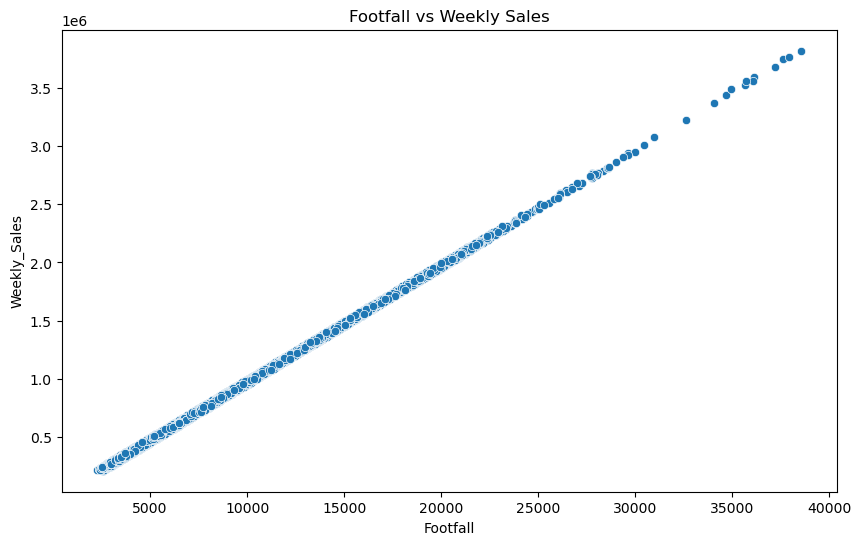

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Footfall', y='Weekly_Sales', data=df)

plt.title('Footfall vs Weekly Sales')

plt.savefig('../Graph/footfall_vs_sales.png')

plt.show()

In [ ]:
df.to_csv('../Data/cleaned_walmart.csv', index=False)

## MACHINE LEARNING

In [5]:
import pandas as pd

df = pd.read_csv("cleaned_walmart.csv")

print(df.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  Footfall  
0  211.096358         8.106     16828  
1  211.242170         8.106     16642  
2  211.289143         8.106     16570  
3  211.319643         8.106     14343  
4  211.350143         8.106     15976  


In [6]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [7]:
from sklearn.model_selection import train_test_split

X = df[['Footfall', 'Holiday_Flag']]

y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [9]:
predictions = model.predict(X_test)

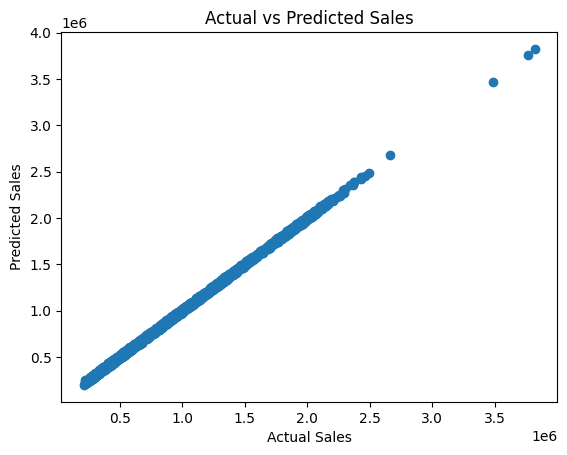

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

**The analysis shows that customer footfall strongly impacts weekly sales. Higher footfall generally results in increased sales revenue. The regression model successfully predicted sales trends using footfall and holiday information.**

In [11]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))